# Python 200 - Week 1: Statistical & Analytical Thinking


# About Me (Khant)

- Junior AI Engineer
- Sophomore student


# Icebreaker Question

- Rate your learning progress so far

- "The average human has fewer than two legs." True or False? 

## Section 1: Describing Data - Central Tendency and Spread

- **Mean** is easy to compute, but it is sensitive to extreme values.
- **Median** stays close to the center when data is skewed or contains outliers.
- **Standard deviation** measures spread in the original units of the data.
- **Variance** measures spread in squared units, which makes it less intuitive to read.
- Two groups can share the same average and still tell very different stories if one is more variable than the other.
- Pandas can summarize groups with `groupby().agg(['mean', 'std'])`.

In [ ]:
import numpy as np
import pandas as pd

print('--- IMPACT OF OUTLIERS ---')
data_with_outlier = [10, 20, 30, 40, 1000]
print('Data:', data_with_outlier)
print('Mean:', np.mean(data_with_outlier))
print('Median:', np.median(data_with_outlier))
print('Variance:', round(np.var(data_with_outlier), 2))
print('Std Dev:', round(np.std(data_with_outlier), 2))

print('\n--- HIGH VARIANCE VS LOW VARIANCE ---')
low_variance_group = [48, 49, 50, 51, 52]
high_variance_group = [10, 30, 50, 70, 90]

print('Low Variance Group Mean:', np.mean(low_variance_group))
print('Low Variance Group Std:', round(np.std(low_variance_group), 2))
print('High Variance Group Mean:', np.mean(high_variance_group))
print('High Variance Group Std:', round(np.std(high_variance_group), 2))

print('\n--- GROUPBY SUMMARY ---')
df_scores = pd.DataFrame({
    'Class': ['A', 'A', 'A', 'B', 'B', 'B'],
    'Score': [62, 68, 70, 84, 88, 90]
})
summary = df_scores.groupby('Class')['Score'].agg(['mean', 'std']).round(2)
print(summary)

--- IMPACT OF OUTLIERS ---
Data: [10, 20, 30, 40, 1000]
Mean: 220.0
Median: 30.0
Variance: 152200.0
Std Dev: 390.13

--- HIGH VARIANCE VS LOW VARIANCE ---
Low Variance Group Mean: 50.0
Low Variance Group Std: 1.41
High Variance Group Mean: 50.0
High Variance Group Std: 28.28

--- GROUPBY SUMMARY ---
        mean   std
Class             
A      66.67  4.16
B      87.33  3.06


21:14:47.929 | ERROR   | prefect.server.services.telemetry - Failed to send telemetry: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)
21:24:49.064 | ERROR   | prefect.server.services.telemetry - Failed to send telemetry: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)
21:34:48.800 | ERROR   | prefect.server.services.telemetry - Failed to send telemetry: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)
21:44:48.557 | ERROR   | prefect.server.services.telemetry - Failed to send telemetry: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)
21:54:48.748 | ERROR   | prefect.server.services.telemetry - Failed to send telemetry: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)


---

## Section 2: Distributions and Visualization

- A **normal distribution** is symmetric and bell-shaped.
- A **right-skewed distribution** has a long tail on the right side.
- An **exponential distribution** is a common model for wait times and other right-skewed data.
- **Histograms** show the overall shape of the data.
- **Boxplots** show the middle 50 percent of the data and help reveal outliers.
- Whiskers usually extend to 1.5 times the IQR, so points beyond them can be treated as potential outliers.

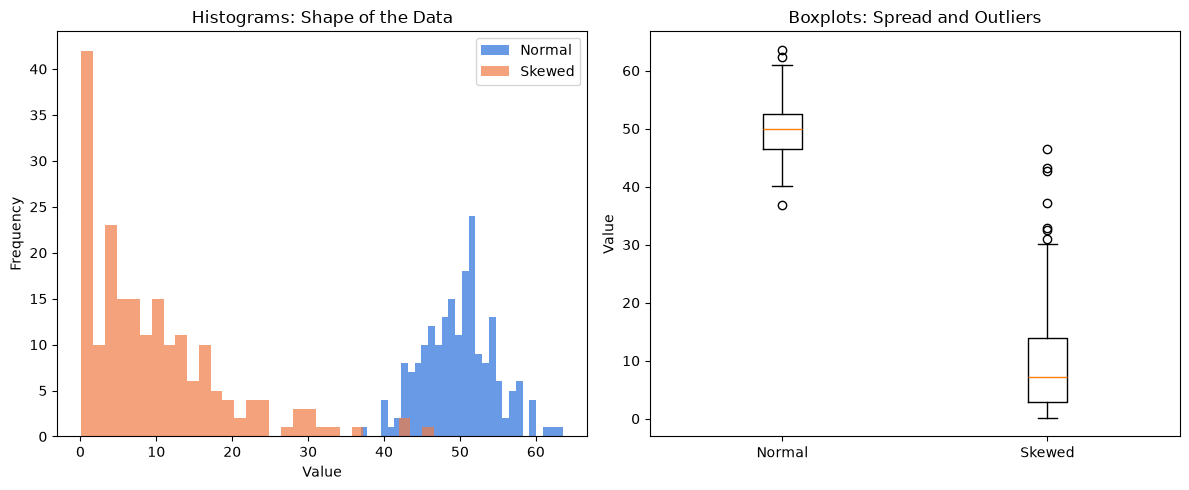

In [14]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
normal_data = np.random.normal(loc=50, scale=5, size=200)
skewed_data = np.random.exponential(scale=10, size=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(normal_data, bins=30, alpha=0.7, label='Normal', color='#2a6fdb')
axes[0].hist(skewed_data, bins=30, alpha=0.7, label='Skewed', color='#ef7b45')
axes[0].set_title('Histograms: Shape of the Data')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot([normal_data, skewed_data], tick_labels=['Normal', 'Skewed'])
axes[1].set_title('Boxplots: Spread and Outliers')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

---

## Section 3: Hypothesis Testing

- **H0** is the default assumption that nothing meaningful changed.
- **H1** is the claim that a real effect or difference exists.
- The **p-value** tells us how surprising the result would be if H0 were true.
- A common threshold is **alpha = 0.05**. If p < 0.05, we reject H0.
- Use an **independent samples t-test** for two unrelated groups.
- Use a **paired t-test** for the same subjects measured twice.
- Use a **one-sample t-test** to compare a sample against a benchmark value.

In [15]:
from scipy import stats

alpha = 0.05

class_a_scores = [65, 70, 68, 72, 66, 64, 69, 71]
class_b_scores = [75, 78, 74, 80, 76, 79, 77, 81]

t_stat, p_val = stats.ttest_ind(class_a_scores, class_b_scores)
print('--- INDEPENDENT SAMPLES T-TEST ---')
print(f'T-statistic: {t_stat:.2f}')
print(f'P-value: {p_val:.5f}')
print('Decision:', 'Reject H0' if p_val < alpha else 'Fail to reject H0')

before = [62, 68, 71, 65, 70, 67, 63, 69]
after = [70, 75, 74, 72, 78, 71, 69, 74]
paired_t, paired_p = stats.ttest_rel(before, after)
print('\n--- PAIRED T-TEST ---')
print(f'T-statistic: {paired_t:.2f}')
print(f'P-value: {paired_p:.5f}')
print('Decision:', 'Reject H0' if paired_p < alpha else 'Fail to reject H0')

scores = [68, 72, 74, 69, 71, 73, 70, 75]
one_sample_t, one_sample_p = stats.ttest_1samp(scores, 70)
print('\n--- ONE-SAMPLE T-TEST ---')
print(f'T-statistic: {one_sample_t:.2f}')
print(f'P-value: {one_sample_p:.5f}')
print('Decision:', 'Reject H0' if one_sample_p < alpha else 'Fail to reject H0')

--- INDEPENDENT SAMPLES T-TEST ---
T-statistic: -6.99
P-value: 0.00001
Decision: Reject H0

--- PAIRED T-TEST ---
T-statistic: -9.17
P-value: 0.00004
Decision: Reject H0

--- ONE-SAMPLE T-TEST ---
T-statistic: 1.73
P-value: 0.12687
Decision: Fail to reject H0


---

## Section 4: Correlation

- Pearson correlation, often written as **r**, measures linear relationship strength and direction.
- Values range from **-1** to **+1**.
- Correlation does **not** imply causation.
- A scatterplot is always worth checking because data shape can matter more than the coefficient alone.

Correlation (r) between sleep and scores: -0.99
P-value: 0.0000

Correlation Matrix:
             Study_Hours  Exam_Score  Video_Games
Study_Hours         1.00        1.00        -0.99
Exam_Score          1.00        1.00        -0.99
Video_Games        -0.99       -0.99         1.00


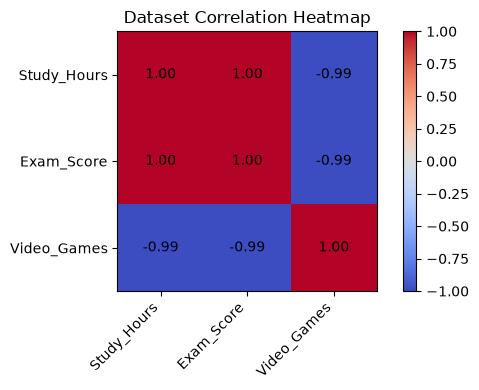

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

exam_scores = [48, 55, 58, 67, 72, 74, 81, 84]
sleep_hours = [8.2, 7.8, 7.3, 6.7, 6.2, 5.8, 5.4, 4.9]

r, p = pearsonr(exam_scores, sleep_hours)
print(f'Correlation (r) between sleep and scores: {r:.2f}')
print(f'P-value: {p:.4f}')

data = pd.DataFrame({
    'Study_Hours': [2, 3, 5, 7, 9],
    'Exam_Score': [60, 65, 75, 85, 95],
    'Video_Games': [10, 8, 5, 3, 1]
})

corr = data.corr(numeric_only=True)
print('\nCorrelation Matrix:')
print(corr.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
image = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for row_index in range(len(corr.index)):
    for col_index in range(len(corr.columns)):
        ax.text(col_index, row_index, f'{corr.iloc[row_index, col_index]:.2f}', ha='center', va='center', color='black')

fig.colorbar(image, ax=ax)
ax.set_title('Dataset Correlation Heatmap')
plt.tight_layout()
plt.show()

---

## Section 5: Data Pipelines and Prefect

- **ETL** stands for Extract, Transform, Load.
- Pipelines make analysis easier to rerun, debug, and share.
- **Prefect** adds retries, logging, and task/flow orchestration.
- In this notebook, the pipeline uses mocked CSV data so it runs without any external files.

In [17]:
import io
import pandas as pd

mock_csv_data = '''id,name,score
1,Alice,85
2,Bob,
3,Charlie,92
4,Dave,
5,Eve,88'''

try:
    from prefect import task, flow, get_run_logger
except ImportError:
    def task(*decorator_args, **decorator_kwargs):
        if decorator_args and callable(decorator_args[0]) and len(decorator_args) == 1 and not decorator_kwargs:
            return decorator_args[0]
        def decorator(func):
            return func
        return decorator

    def flow(*decorator_args, **decorator_kwargs):
        if decorator_args and callable(decorator_args[0]) and len(decorator_args) == 1 and not decorator_kwargs:
            return decorator_args[0]
        def decorator(func):
            return func
        return decorator

    class _FallbackLogger:
        def info(self, message):
            print(f'INFO: {message}')

    def get_run_logger():
        return _FallbackLogger()

    print('Prefect is not installed, so this cell is using a lightweight fallback.')

@task(retries=2, retry_delay_seconds=1)
def extract_data():
    logger = get_run_logger()
    logger.info('Extracting data from source...')
    return pd.read_csv(io.StringIO(mock_csv_data))

@task
def transform_data(df):
    logger = get_run_logger()
    logger.info(f'Original row count: {len(df)}')
    clean_df = df.dropna(subset=['score']).copy()
    clean_df['score'] = clean_df['score'].astype(int)
    logger.info(f'Cleaned row count: {len(clean_df)}')
    return clean_df

@flow
def my_etl_pipeline():
    raw_data = extract_data()
    cleaned_data = transform_data(raw_data)
    print('\n--- Final Cleaned Data ---')
    print(cleaned_data)

my_etl_pipeline()

20:50:35.732 | INFO    | Flow run 'important-dog' - Beginning flow run 'important-dog' for flow 'my-etl-pipeline'

20:50:36.507 | INFO    | Task run 'extract_data-996' - Extracting data from source...

20:50:37.177 | INFO    | Task run 'extract_data-996' - Finished in state Completed()

20:50:37.306 | INFO    | Task run 'transform_data-c68' - Original row count: 5

20:50:37.984 | INFO    | Task run 'transform_data-c68' - Cleaned row count: 3

20:50:37.990 | INFO    | Task run 'transform_data-c68' - Finished in state Completed()


--- Final Cleaned Data ---
   id     name  score
0   1    Alice     85
2   3  Charlie     92
4   5      Eve     88


20:50:38.215 | INFO    | Flow run 'important-dog' - Finished in state Completed()

---

## Section 6: Core Data Stack Overview

- **NumPy** is the numerical engine for fast array math and vectorization.
- **Pandas** organizes and cleans data in tables.
- **Matplotlib** turns numbers into visual stories.
- Good analysis usually combines all three.

NumPy array math: [12. 24. 36. 48.]

Pandas groupby aggregation:
         mean  sum
Region            
North   175.0  350
South   200.0  400


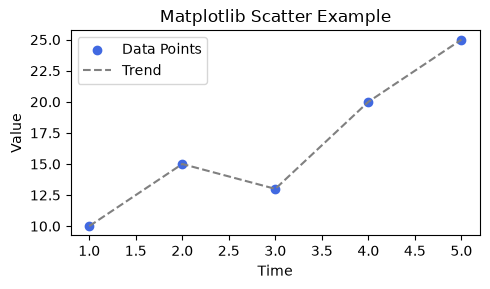

20:54:48.332 | ERROR   | prefect.server.services.telemetry - Failed to send telemetry: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)
21:04:48.277 | ERROR   | prefect.server.services.telemetry - Failed to send telemetry: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_prices = np.array([10, 20, 30, 40])
taxed_prices = base_prices * 1.20
print('NumPy array math:', taxed_prices)

df_sales = pd.DataFrame({
    'Region': ['North', 'North', 'South', 'South'],
    'Sales': [150, 200, 100, 300]
})
print('\nPandas groupby aggregation:')
print(df_sales.groupby('Region')['Sales'].agg(['mean', 'sum']))

x_data = np.array([1, 2, 3, 4, 5])
y_data = np.array([10, 15, 13, 20, 25])

plt.figure(figsize=(5, 3))
plt.scatter(x_data, y_data, color='royalblue', label='Data Points')
plt.plot(x_data, y_data, color='gray', linestyle='--', label='Trend')
plt.title('Matplotlib Scatter Example')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

---

## Wrap-Up

